### Lifetime Maximum Intensity distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import sys
import os, glob
import xarray as xr

from scipy.stats import gaussian_kde



## most correct would probably be to seperate this... 
### get variables from chaz run
import Namelist as gv

### TEMPORARY (hopefully) code snippet so that the HTML view of datasets/dataarrays is viewable in darkmode on jupyter lab/VS code
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))


In [2]:
# base_dir      = "/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/"
# file_pattern  = "global_2019_2ens00[0-9]_pre.nc"

# filenames = glob.glob(os.path.join(base_dir, file_pattern))

In [ ]:
version_configs = {
    'ERA5-Original-CHAZ': {
        'base_dir': "/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/",
        "year_range": (1950, 2020),     
        "output_dir": "/home/miriamn/CHAZ/CHAZvectorized/output/",#gv.output_path,
        #"file_pattern": "global_2019_2ens*_pre.nc",
        "file_pattern": "global_2019_2ens00[0-3]_pre.nc",
        "name": 'ERA5-Original-CHAZ',
        
    },
    'ERA5-Updated-CHAZ': {
        'base_dir': gv.output_path,
        "year_range": (gv.Year1, gv.Year2),
        "file_pattern": "ERA5_*_ens*.nc",
        "output_dir": gv.output_path, #"/home/miriamn/CHAZ/CHAZvectorized/output/",
        "name": 'ERA5-Updated-CHAZ',
    }
}

def _get_basin_mask(latitude, longitude, basin):
    """
    Determine which storms have at least one track point inside a selected ocean basin.

    latitude, longitude:
        xarray.DataArray with dimensions (lifelength, stormID)

    Returns:
        1-D boolean numpy array with length stormID
    """

    if basin == 'ATL':
        # ~100°W–20°E, 0–60°N
        point_mask = (
            (latitude >= 0) &
            (latitude <= 60) &
            (
                (longitude >= 260) |
                (longitude <= 20)
            )
        )

    elif basin == 'WNP':
        # ~100°E–180°E, 0–50°N
        point_mask = (
            (latitude >= 0) &
            (latitude <= 50) &
            (longitude >= 100) &
            (longitude <= 180)
        )

    elif basin == 'GLOBAL':
        # 0–360°, -60–60°
        point_mask = (
            (latitude >= -60) &
            (latitude <= 60)
        )

    else:
        raise ValueError(
            f"Unknown basin: {basin}. "
            "Choose from 'ATL', 'WNP', or 'GLOBAL'."
        )

    ## A storm counts as 'in the ocean basin' if ANY part of its track is within the basin.
    storm_mask = point_mask.any(dim='lifelength')

    return storm_mask.values


def _enumerate_files(cfg):
    base_dir      = cfg["base_dir"]
    file_pattern  = cfg["file_pattern"]
    name          = cfg["name"]
    year_range    = cfg["year_range"]

    filenames = glob.glob(os.path.join(base_dir, file_pattern))
    years_span = year_range[1] - year_range[0] + 1

    if name == 'ERA5-Updated-CHAZ':
        years = {str(y) for y in range(year_range[0], year_range[1] + 1)}
        fnames = sorted([
            f for f in filenames
            if f.split('_')[1] in years])

        nyears_eff = len(fnames)

    elif name == 'ERA5-Original-CHAZ':
        fnames = sorted(filenames)
        nyears_eff = years_span * max(1, len(fnames))

    else:
        raise ValueError(f"Unknown configuration: {name}")

    #return fnames   
    return fnames, nyears_eff


def get_vmax(filenames, basin_key, output_path):
    """Read all files and return maximum wind speed for each storm/event."""

    vmax_all = []

    for filename in filenames:
        #print(f"Reading: {filename}")

        with xr.open_dataset(filename) as ds:
            # lat/lon are data variables associated with stormID
            lat = ds.latitude
            lon = ds.longitude

            basin_mask = _get_basin_mask(
                lat,
                lon,
                basin_key
            )

            # Mwspd dimensions: (ensembleNum, lifelength, stormID)
            #
            # Find maximum over storm lifetime.
            # vmax dimensions: (ensembleNum, stormID)
            vmax = ds.Mwspd.max(dim='lifelength', skipna=True)

            # Keep only storms in selected basin
            vmax = vmax[:, basin_mask]

            # Remove NaNs
            vmax = vmax.values
            vmax = vmax[~np.isnan(vmax)]

            vmax_all.append(vmax)

    if not vmax_all:
        raise ValueError("No valid data found.")

    vmax_concat = np.concatenate(vmax_all)

    print(f'saving vmax array to {output_path}')
    np.save(output_path, vmax_concat)

    return vmax_concat


def plot_LMI(basin_key):
    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {
        'ERA5-Original-CHAZ': 'royalblue',
        'ERA5-Updated-CHAZ': 'darkorange',
    }

    for name, cfg in version_configs.items():
    
        filenames, nyears_eff = _enumerate_files(cfg)

        print(
            f"{name}: "
            f"{len(filenames)} files, "
            f"{nyears_eff} effective years"
        )   
        ## check if vmax has already been calculated:

        #out_root = cfg["output_dir"]
        out_root = gv.output_path
        out_dir = os.path.join(out_root, "VMAX")
        output_path = os.path.join(out_dir, f"vmax_{name}_{basin_key}_{nyears_eff}.npy")

        if os.path.exists(output_path):
            ## IMPORT
            vmax = np.load(output_path)
            print(output_path)
        else:
            vmax = get_vmax(filenames, basin_key, output_path)

        # bins = np.arange(25, 200, 5)
        
        # ### CHANGE THIS TO PDF
        # plt.hist(vmax, bins = bins, density = True, 
        #          alpha = 0.5, label = name, color = colors[name])

        # Remove NaNs/infinite values
        vmax = vmax[np.isfinite(vmax)]

        # Kernel density estimate
        kde = gaussian_kde(vmax)

        # Wind-speed range
        # x_grid = np.linspace(
        #     max(0, vmax.min()),
        #     vmax.max(),
        #     500
        # )

        x_grid = np.linspace(25, 200, 500)

        pdf = kde(x_grid)

        ax.plot(
            x_grid,
            pdf,
            color=colors[name],
            linewidth=2,
            label=name
        )

    ax.set_xlabel('Max Wind Speed (m/s)')
    ax.set_ylabel('Probability Density')

    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()

    plt.title(f'Lifetime Maximum Intensity - {basin_key}')
    plt.legend()
    plt.show()

    return vmax

        

ERA5-Original-CHAZ: 4 files, 284 effective years
saving vmax array to /data0/miriamn/CHAZvectorized/output/100526-training-test/VMAX/vmax_ERA5-Original-CHAZ_GLOBAL_284.npy
ERA5-Updated-CHAZ: 225 files, 225 effective years
saving vmax array to /data0/miriamn/CHAZvectorized/output/100526-training-test/VMAX/vmax_ERA5-Updated-CHAZ_GLOBAL_225.npy


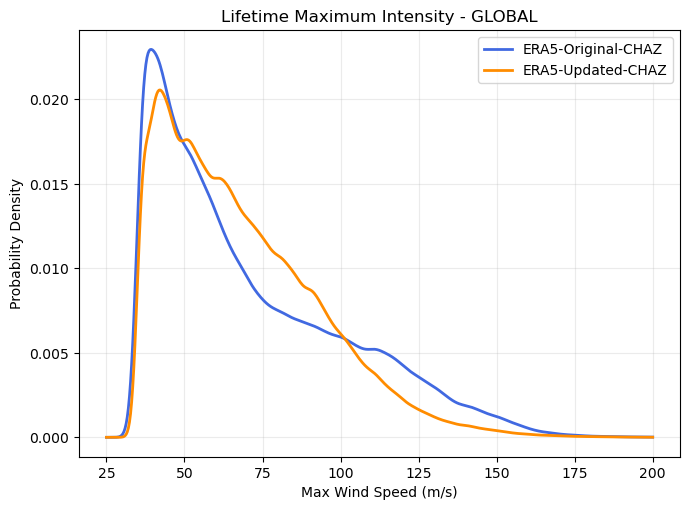

ERA5-Original-CHAZ: 4 files, 284 effective years
saving vmax array to /data0/miriamn/CHAZvectorized/output/100526-training-test/VMAX/vmax_ERA5-Original-CHAZ_ATL_284.npy
ERA5-Updated-CHAZ: 225 files, 225 effective years
saving vmax array to /data0/miriamn/CHAZvectorized/output/100526-training-test/VMAX/vmax_ERA5-Updated-CHAZ_ATL_225.npy


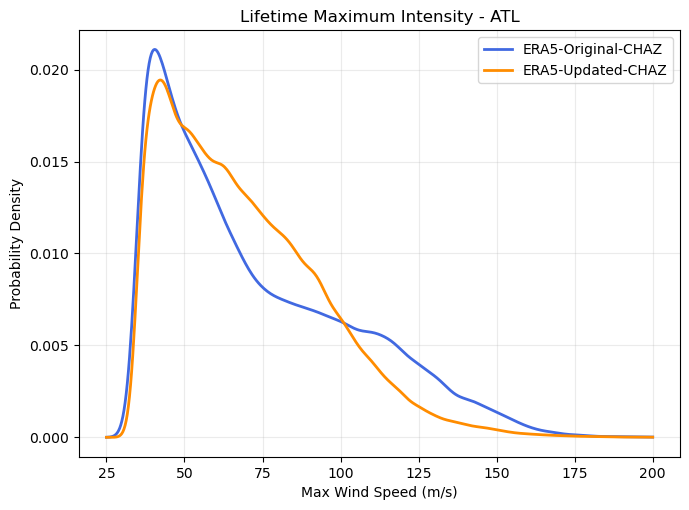

ERA5-Original-CHAZ: 4 files, 284 effective years
saving vmax array to /data0/miriamn/CHAZvectorized/output/100526-training-test/VMAX/vmax_ERA5-Original-CHAZ_WNP_284.npy
ERA5-Updated-CHAZ: 225 files, 225 effective years
saving vmax array to /data0/miriamn/CHAZvectorized/output/100526-training-test/VMAX/vmax_ERA5-Updated-CHAZ_WNP_225.npy


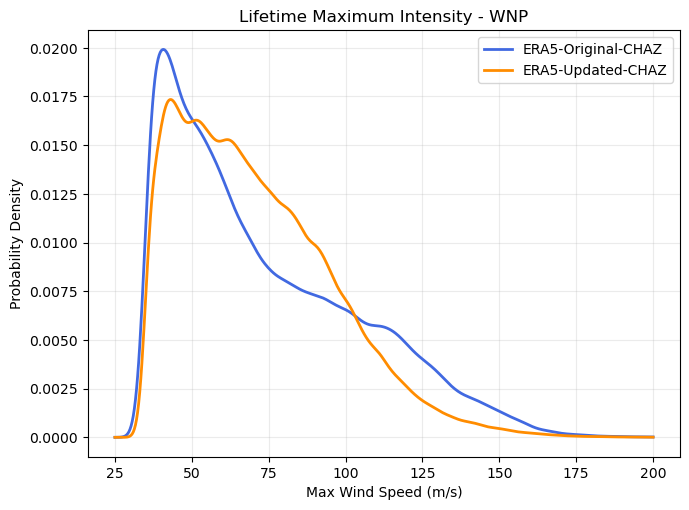

array([76.80636115, 90.07164285, 40.51227757, ..., 84.84663028,
       46.82742488, 74.5986229 ], shape=(361888,))

In [7]:
## open vmax logic might not work again, need to add effective year to output path

plot_LMI('GLOBAL')
plot_LMI('ATL')
plot_LMI('WNP')

#### Previous Version

In [ ]:
### need to update to support multiple track realizations for updated data 

## ORIGINAL
## n.b. July 22nd figures in slide dek are a mix of ens000 and ens059, but results are largely similar
ds_old_tmp = xr.open_dataset('/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens000_pre.nc').load()
mask = (ds_old_tmp['year'] >= 2000) & (ds_old_tmp['year'] <= 2009)
ds_old = ds_old_tmp.isel(stormID=mask)


### UPDATED
def preprocess(ds):
    # each file's `year` variable is constant across stormID, so grab the first value
    yr = int(ds['year'].values[0])
    return ds.expand_dims(year_dim=[yr])

## cheeky way to just get 2000-2009 (for now)
filenames = sorted(glob.glob('output/ERA5_200*_ens000.nc'))

ds_new = xr.open_mfdataset(
    filenames,
    preprocess=preprocess,
    combine="nested",
    concat_dim="year_dim",
).load()

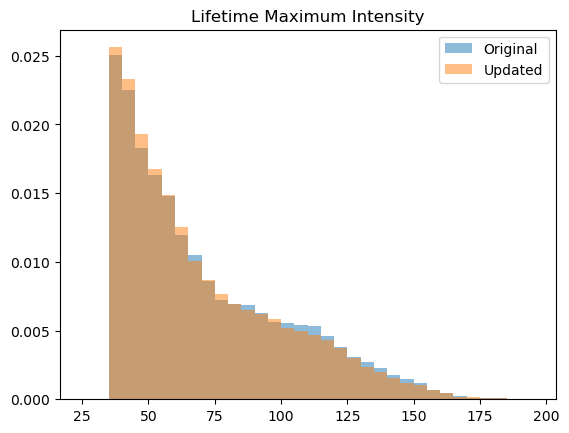

In [ ]:
vmax = np.nanmax(ds_old['Mwspd'].values, axis=1)
plt.hist(vmax.flatten(), bins=np.arange(25,200,5), density=True,
         alpha = 0.5,
         label = 'Original' )


vmax = np.nanmax(ds_new['Mwspd'].values, axis=2)
plt.hist(vmax.flatten(), bins=np.arange(25,200,5), 
         density=True, alpha = 0.5, label = 'Updated')
plt.title('Lifetime Maximum Intensity')

plt.legend()

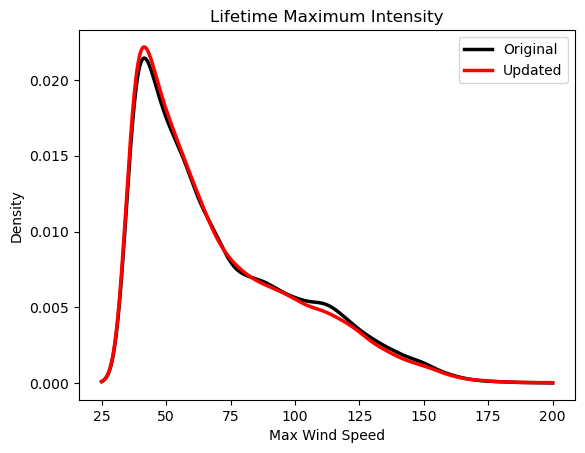

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x_grid = np.linspace(25, 200, 500)

# Original
vmax_old = np.nanmax(ds_old['Mwspd'].values, axis=1).flatten()
vmax_old = vmax_old[~np.isnan(vmax_old)]
kde_old = gaussian_kde(vmax_old)
plt.plot(x_grid, kde_old(x_grid), color='black', linewidth=2.5, label='Original')

# Updated
vmax_new = np.nanmax(ds_new['Mwspd'].values, axis=2).flatten()
vmax_new = vmax_new[~np.isnan(vmax_new)]
kde_new = gaussian_kde(vmax_new)
plt.plot(x_grid, kde_new(x_grid), color='red', linewidth=2.5, label='Updated')

plt.title('Lifetime Maximum Intensity')
plt.xlabel('Max Wind Speed')
plt.ylabel('Density')
plt.legend()

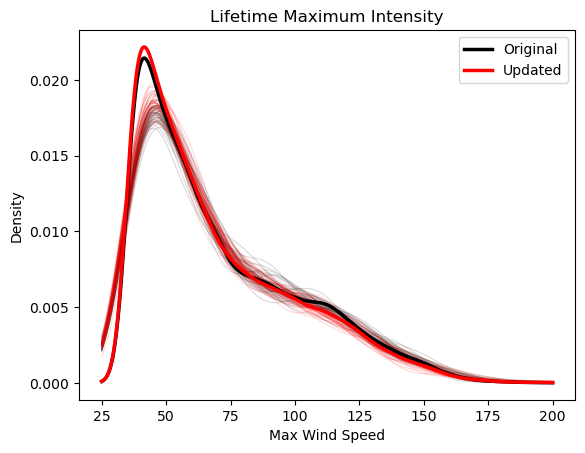

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x_grid = np.linspace(25, 200, 500)

def plot_members(ds, color):
    vmax = ds['Mwspd'].max(dim='lifelength', skipna=True)  # dims: (year_dim, ensembleNum, stormID)

    for m in ds['ensembleNum'].values:
        vmax_m = vmax.sel(ensembleNum=m).values.flatten()
        vmax_m = vmax_m[~np.isnan(vmax_m)]
        if len(vmax_m) < 2:
            continue
        kde_m = gaussian_kde(vmax_m)
        plt.plot(x_grid, kde_m(x_grid), color=color, alpha=0.15, linewidth=0.8)

plot_members(ds_old, 'black')
plot_members(ds_new, 'red')

# Original (pooled)
vmax_old = ds_old['Mwspd'].max(dim='lifelength', skipna=True).values.flatten()
vmax_old = vmax_old[~np.isnan(vmax_old)]
kde_old = gaussian_kde(vmax_old)
plt.plot(x_grid, kde_old(x_grid), color='black', linewidth=2.5, label='Original')

# Updated (pooled)
vmax_new = ds_new['Mwspd'].max(dim='lifelength', skipna=True).values.flatten()
vmax_new = vmax_new[~np.isnan(vmax_new)]
kde_new = gaussian_kde(vmax_new)
plt.plot(x_grid, kde_new(x_grid), color='red', linewidth=2.5, label='Updated')

plt.title('Lifetime Maximum Intensity')
plt.xlabel('Max Wind Speed')
plt.ylabel('Density')
plt.legend()